# AP 155 Lab Exercise
---
## Exercise 1: Numbers in Computers

_Instructions_: 
- **Report figure (Problem 1):** Answer and follow the (Modified) Gezerlis 2.6
- **Report figure (Problem 2):** Answer and follow the (Modified) Gezerlis 2.8

### Student Information
- _Full Name (Last Name, First Name)_: Abellana, Karl Gian
- _Student No._: 2024-09545
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

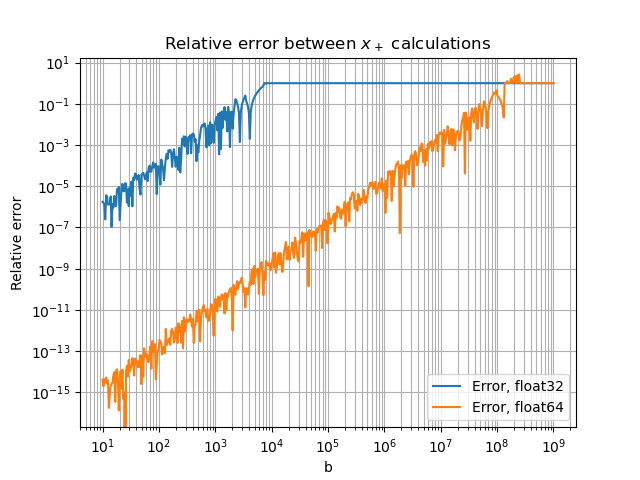

When calculating for $x_+$ in the quadratic formula, we must be careful with catastrophic cancellation. As $b^{2}>>4ac$, the numerator is approximately $-b+b$. In order to calculate it correctly, we must use the fact that $x_{+}=\frac{c}{ax_{-}}$. The figure above shows how the relative error increases as b increases, this highlights the importance of working around catastrophic cancellations to make sure our calculations remain precise. Observe that the ```float32``` has higher errors than ```float64``` dtype, this shows that avoiding catastrophic cancellations is important for less precise dtypes, which is good to note for writing memory efficient code.

### Problem 2
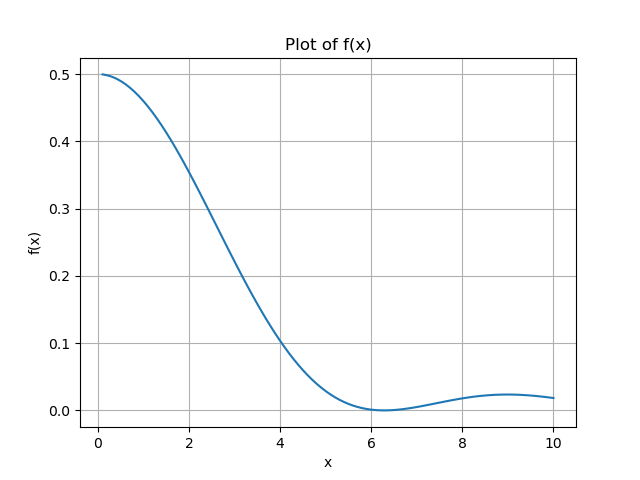
Figure 1

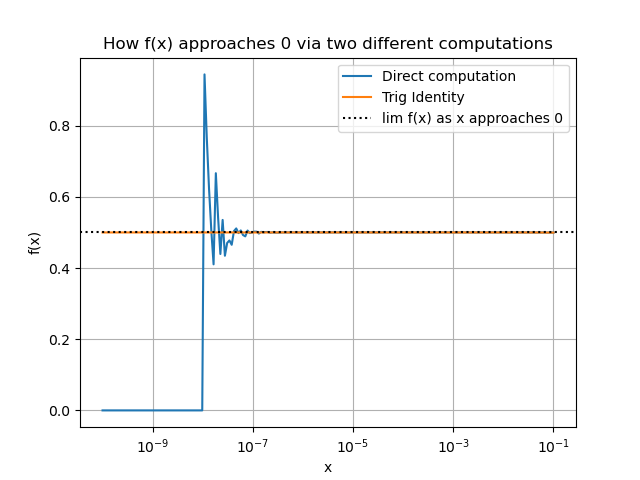
Figure 2

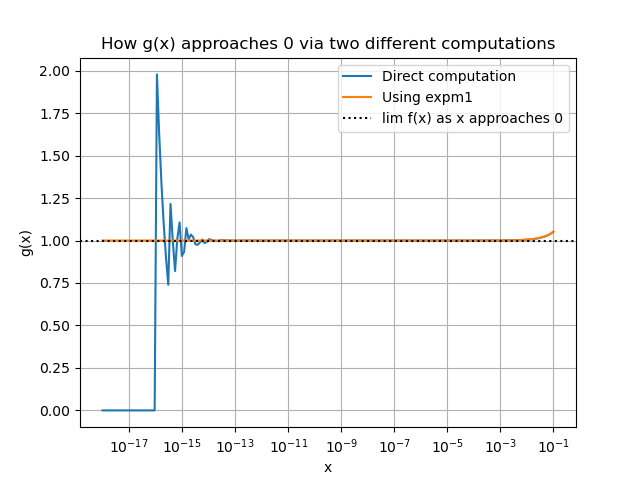
Figure 3

Problem 2 had us understand multiple ways of working around catastrophic cancellations. We can use identities, or built in functions. In this problem, I renamed the second equation to g(x) to avoid ambiguity. A logspace numpy array was made to be plugged into the direct calculation functions and the new ones in order to observe their behavior as it approaches the point where the cancellation occurs as it is shown in the figure above. As some inputs are rounded up, some are rounded down, it oscillates around the true value and then collapse to 0.

Figure 1 showed the plot of f(x) from 0 to 10, and here we expect the evaluation of f(0) to be 0.5. However, the resulting direct calculation gives us approximately 0.77. After using trigonometric identities to resolve the catastrophic cancellation, we now get 0.5 as shown in Figure 2. The same case is shown in Figure 3, where g(x) has a catastrophic cancellation occuring when x = 0. We address this by introducing ```np.expm1()```, which is a built-in function whose purpose is to solve the catastrophic cancellation occuring with $e^x-1$. Again, we plot the direct calculation against the calculation using ```np.expm1()``` and see how the latter approaches the correct value precisely while the former oscillates around the true value before collapsing due to rounding errors.

### Other comments


---
## Section 2: Code

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)

Take the standard quadratic equation: $ax^2 + bx + c = 0$, whose solutions are 

$$x_{\pm}=\frac{-b \pm \sqrt{b^2-4ac}}{2a}$$

Take $b>0$ for concreteness. It is easy to see that when $b^2 >> ac$, we don't get a catastrophic cancellation when evaluating $b^2 - 4ac$ (we may still get a "benign" cancellation). Furthermore, $\sqrt{b^2-4ac} \approx b$. 

However, this means that $x_+$ will involve catastrophic cancellation in the numerator. We will employ an analytical trick in order to help us preserve significant figures. Observe that the product of the two roots must obey 

$$x_+ x_- = \frac{c}{a}$$

The answer now presents itself: use the standard quadratic formula to calculate $x_-$, for which no catastrophic cancellation takes place. Then, use $x_+ x_- = \frac{c}{a}$ to calculate $x_+$. Notice that you end up calculating $x_+$, via division only (i.e. without a catastrophic cancellation). 

Write a Python code (use `np.sqrt()`) that evaluates and prints out **(a)** $x_-$, **(b)** $x_+$ using the "bad formula", and **(c)** $x_+$ using the "good formula". 

Take $a=1$, $c=1$, $b=10^8$. Discuss the answers.

Lastly, **(d)** [FIGURE] Visualize the loss of precision by plotting the relative error of the "bad" $x_+$ formula. Vary $b$ using a log scaling (e.g., from $10^4$ to $10^9$). To highlight the effect of hardware limits, evaluate the bad formula using both 32-bit (np.float32) and 64-bit (np.float64) precision, comparing them against the "good" formula as the baseline.

In [50]:
import numpy as np
import matplotlib.pyplot as plt

x_minus: -1e+08
x_plus calculated badly: -7.450580596923828e-09
x_plus calculated correctly: -1e-08


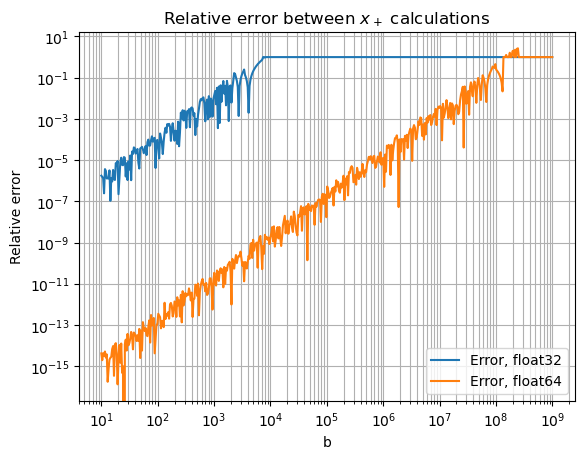

In [57]:
# insert your code here
# generate required outputs and plots
# do not forget axes labels 

# there is a catastrophic cancellation involving the calculation of root x_+
# however, there is no catastrophic cancellation involving the calcuation of root x_-
# we can first calculate root x_- and use the fact that the product of the roots are equal to c/a.

# (a) calculating x_-:
def solve_x_minus(a, b, c):
    return (-b-np.sqrt(b**2-(4*a*c)))/(2*a)

# (b) calculating x_+ badly:
def solve_x_plus_catastrophically(a, b, c):
    return (-b+np.sqrt(b**2-(4*a*c)))/(2*a)

# (c) calculating x__ correctly:
def solve_x_plus_correctly(a, b, c):
    x_minus = solve_x_minus(a, b, c)
    return c/(a*x_minus)

# Test cases
print(f"x_minus: {solve_x_minus(1, 1e8, 1):.0e}")
print(f"x_plus calculated badly: {solve_x_plus_catastrophically(1, 1e8, 1)}")
print(f"x_plus calculated correctly: {solve_x_plus_correctly(1, 1e8, 1)}")

# Plotting relative error
bs = np.logspace(1, 9, num = 500, endpoint = True, base = 10.0)

# For float32
bs_float32 = np.float32(bs)
x_plus_catastrophic_array_float32 = solve_x_plus_catastrophically(np.float32(1), bs_float32, np.float32(1))
x_plus_correctly_array_float32 = solve_x_plus_correctly(np.float32(1), bs_float32, np.float32(1))
errors_float32 = np.abs((x_plus_catastrophic_array_float32 - x_plus_correctly_array_float32) / x_plus_correctly_array_float32)

# For float64
bs_float64 = np.float64(bs)
x_plus_catastrophic_array_float64 = solve_x_plus_catastrophically(np.float64(1), bs_float64, np.float64(1))
x_plus_correctly_array_float64 = solve_x_plus_correctly(np.float64(1), bs_float64, np.float64(1))
errors_float64 = np.abs((x_plus_correctly_array_float64 - x_plus_catastrophic_array_float64) / x_plus_correctly_array_float64)

plt.loglog(bs, errors_float32, label='Error, float32')
plt.loglog(bs, errors_float64, label='Error, float64')
plt.xlabel('b')
plt.ylabel('Relative error')
plt.title('Relative error between $x_+$ calculations')
plt.grid(True, which = 'both')
plt.legend()
plt.savefig("relative_error.png")
plt.show()

#### Problem 1 code summary

I first created three functions to calculate $x_-$ and $x_+$, badly and correctly. After showing the test cases, I created a logspace array using numpy. Using this array, it was easy to pass it through the functions without for loops or list comprehensions. I then get the relative error by subtracting the $x_+$ calculated badly and $x_+$ calculated correctly on the array, then get the absolute value. Using matplotlib, 

---

### Problem 2: Singularity (Gezerlis 2.8)

#### Part 1:

We will study the following function:

$$f(x) = \frac{1-\cos x}{x^2}$$

**(a)** Start by plotting the function, with a step size of $0.1$ from $x=0.1$ to $x=10$. This should give you some idea of the values you should expect for $f(x)$ at small $x$. You can do this by using `np.arange()` to generate a `numpy array` that you will feed to a function that you will define.

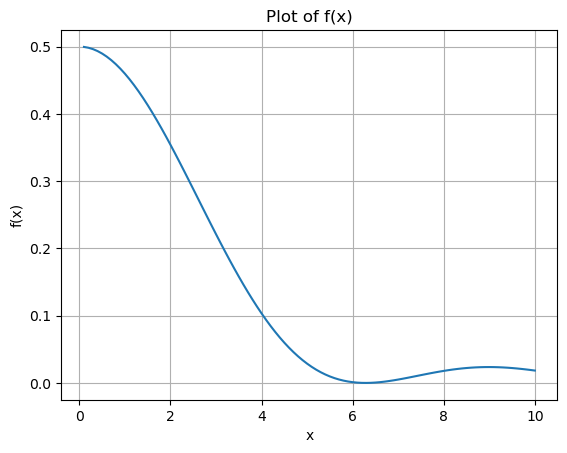

In [59]:
# write code here

# function
def f(x):
    return (1-np.cos(x))/(x**2)

# creating our x values
start = 0.1
stop = 10
step = 0.1
xs = np.arange(start, stop+step, step) # stop+step in order to include the endpoint
fxs = f(xs)

plt.grid(True)
plt.plot(xs, fxs)
plt.ylabel('f(x)')
plt.xlabel('x')
plt.title('Plot of f(x)')
plt.savefig("fx plot")
plt.show()

**(b)** Verify your previous hunch by taking the limit as $x \longrightarrow 0$ and using L'Hopital's rule. You will submit this at the end of the class on a piece of paper.

**(c)** Now, see what value you find for $f(x)$ when $x=1.2 \times 10^{-8}$. Does this make sense qualitatively?
- No, it should be approaching 0.5

In [53]:
# write code here
f(1.2e-8)

0.7709882115452477

**(d)** Use a trigonometric identity to avoid the cancellation. Evaluate the new function at $x=1.2 \times 10^{-8}$ and compare with your analytical answer for $x \longrightarrow 0$.

In [54]:
def f_new(x):
    return (2*(np.sin(x/2))**2)/(x**2)
f_new(1.2e-8)

0.5

**(e)** [FIGURE] Produce a figure that compares how $f(x)$ approaches a certain value as $x \longrightarrow 0$, between directly computing $f(x)$ and by using a trigonometric identity to "avoid the cancellation". 

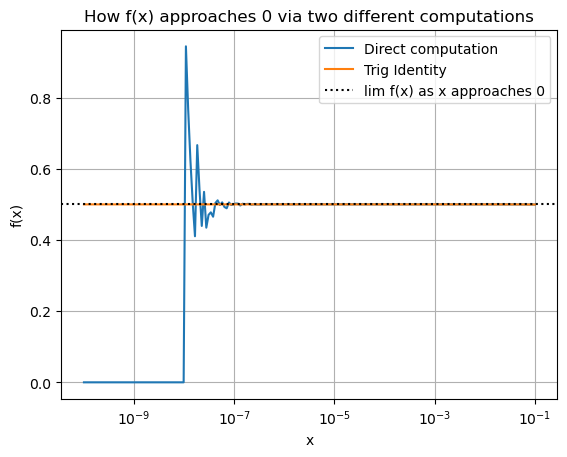

In [58]:
# new variable names to avoid conflict from the previous plot
x_array2 = np.logspace(-1, -10, num = 200, endpoint = True, base = 10.0)
fx_array2 = f(x_array2)
f_new_array = f_new(x_array2)

plt.semilogx(x_array2, fx_array2, label = 'Direct computation')
plt.semilogx(x_array2, f_new_array, label = 'Trig Identity')
plt.axhline(y = 0.5, color = 'black', linestyle=':', label = 'lim f(x) as x approaches 0')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('How f(x) approaches 0 via two different computations')
plt.grid(True)
plt.legend()
plt.savefig("fx.png")
plt.show()

**Bonus**: also compare part with different hardware floating-point precisions: 16/32/64/128-bit. 

#### Part 2:

Consider the function 
$$ g(x) = \frac{e^x - 1}{x}$$

**(a)** For which values of x does the catastrophic cancellation occur? 

- The catastrophic cancellation occurs as $x$ approaches 0, since the numerator $e^x - 1$ will tend to 0: $e^0 - 1 = 0$

**(b)**  How can we resolve the catastrophic cancellation? 

- We can use the special function np.expm1 that calculates $e^x - 1$ with high precision for $x$ values approaching 0, acoiding the catastrophic cancellation.

**(c)**  [FIGURE] Plot the g(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



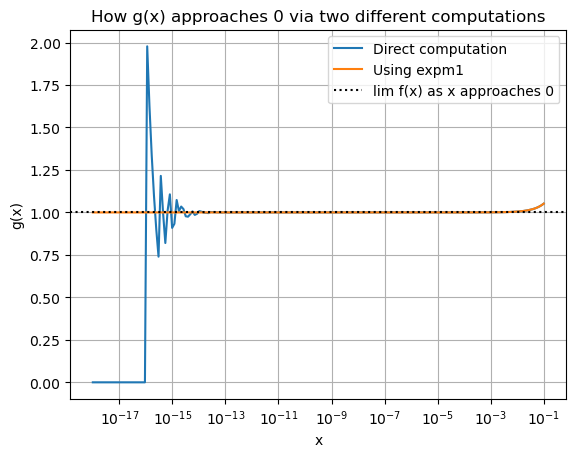

In [56]:
# ur code
# using g(x) instead of f(x) here because of conflicts with the codes above
def g(x):
    return (np.e**x - 1)/x

def g_new(x):
    return np.expm1(x)/x

# we can use the same x_array2
x_array2 = np.logspace(-1, -18, num = 200, endpoint = True, base = 10.0)
gx_array = g(x_array2)
gx_new_array = g_new(x_array2)

plt.semilogx(x_array2, gx_array, label = 'Direct computation')
plt.semilogx(x_array2, gx_new_array, label = 'Using expm1')
plt.axhline(y = 1, color = 'black', linestyle=':', label = 'lim f(x) as x approaches 0')

plt.xlabel('x')
plt.ylabel('g(x)')
plt.title('How g(x) approaches 0 via two different computations')
plt.grid(True)
plt.legend()
plt.savefig('gx.png')
plt.show()

#### Problem 2 code summary

The codes were created to highlight catastrophic cancellation on singularity cases. Similar to problem 1, the process of writing the code is straightforward; create the function that represents $f(x)$, create an array using ```np.logspace()```, pass that array through $f(x)$, and then plot it using matplotilb. On the last part, it was shown that there are special numpy functions that exist to aid us in avoiding catastrophic cancellations.

---
## Section 3: Background

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

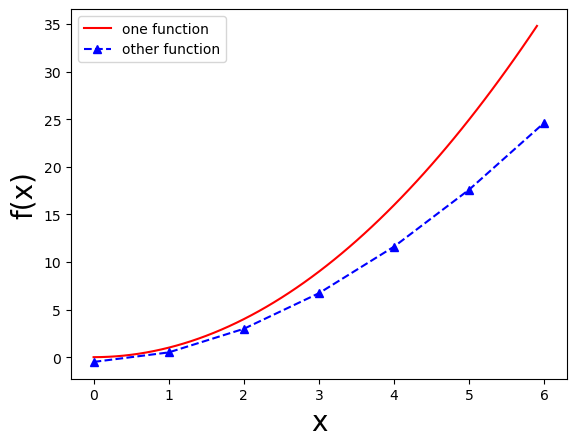

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

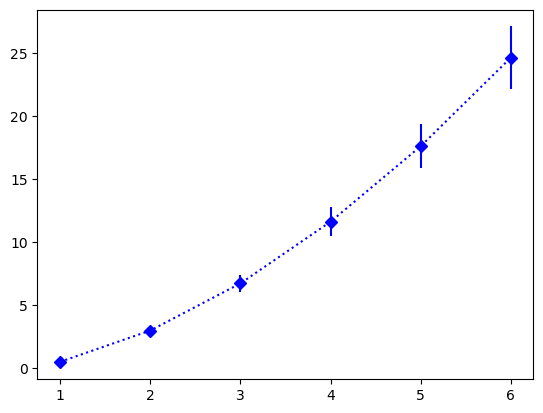

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])